# Module 4 - Interactive Alignment 
Notes: 
- This notebook requires you to have `hisat2`, `samtools`, and `subread`, installed on your system. If you do not have these installed, please follow the instructions below.
- You will also need an active internet connection to download the data and reference genome index.


### Learning Objectives:
- Understand the basics of sequence alignment and its importance in RNA-seq analysis.
- Learn how to use `hisat2` for aligning RNA-seq reads to a reference genome.
- Gain preliminary exposure to `samtools` for manipulating and analyzing SAM/BAM files
- First example of quantifying gene expression using `featureCounts` from the `subread` package.


### Install the necessary software packages using conda:

Either run this command in your terminal:

`conda install -c bioconda hisat2 samtools subread`

or alternatively, you can run the cell below:

In [48]:
!conda install -y -c bioconda hisat2 samtools subread

Retrieving notices: done
Channels:
 - bioconda
 - conda-forge
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.1.1
    latest version: 25.9.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /Users/loyalgoff/miniforge3/envs/neurogenomics

  added / updated specs:
    - hisat2
    - samtools
    - subread


The following packages will be UPDATED:

  openssl                                  3.5.3-h5503f6c_1 --> 3.5.4-h5503f6c_0 




Preparing transaction: done
Verifying transaction: done
Executing transaction: done


As part of this notebook, we will need to download a reference genome index for mouse. This is a pre-built index that HISAT2 can use to align reads. The index is about 1.5GB in size, so it may take a few minutes to download.

In [ ]:
%%bash
curl -O https://genome-idx.s3.amazonaws.com/hisat/mm10_genome.tar.gz
tar -xzf mm10_genome.tar.gz
rm mm10_genome.tar.gz

Ok - so we have an idea of how to make data experimentally from the last lecture, but now we have to think about how to analyze some data!

I'm going to steal from the _lovely_ [Galaxy project](https://galaxyproject.org/) for this tutorial - specifically here: [Transcriptomics](https://training.galaxyproject.org/training-material/topics/transcriptomics/)

We are going to work from RNA-seq data from [Fu et al.](https://www.nature.com/articles/ncb3117) where they sequenced basal and luminal cells from breast tissue of nulliparous, pregnant, or lactating female mice.

The first thing we are going to do is to grab the "FASTQ" files.

FASTQ [Wiki](https://en.wikipedia.org/wiki/FASTQ_format) is a plain text file that encodes for a DNA sequence - along with how confident (quality score) we are that the read is correct.

For the purposes of instruction here and to make sure it runs smoothly, we are going to use a downsampled dataset that is only 1000 reads from each sample, hosted at [Zenodo](https://zenodo.org/record/4249555)

First, let's setup a table of the metadata for this dataset (information about the data).


In [ ]:
import pandas as pd

First, we will build a pandas dataframe to hold all of our sample information, including the URLs to download the FASTQ files from Zenodo.

In [49]:
meta = pd.DataFrame(
    data={
        "sampleid": [
            "MCL1-DL",
            "MCL1-DK",
            "MCL1-DJ",
            "MCL1-DI",
            "MCL1-DH",
            "MCL1-DG",
            "MCL1-LF",
            "MCL1-LE",
            "MCL1-LD",
            "MCL1-LC",
            "MCL1-LB",
            "MCL1-LA",
        ],
        "celltype": [
            "basal",
            "basal",
            "basal",
            "basal",
            "basal",
            "basal",
            "luminal",
            "luminal",
            "luminal",
            "luminal",
            "luminal",
            "luminal",
        ],
        "mousetype": [
            "lactate",
            "lactate",
            "virgin",
            "virgin",
            "pregnant",
            "pregnant",
            "lactate",
            "lactate",
            "pregnant",
            "pregnant",
            "virgin",
            "virgin",
        ],
        "url": [
            "https://zenodo.org/record/4249555/files/SRR1552455.fastq.gz",
            "https://zenodo.org/record/4249555/files/SRR1552454.fastq.gz",
            "https://zenodo.org/record/4249555/files/SRR1552453.fastq.gz",
            "https://zenodo.org/record/4249555/files/SRR1552452.fastq.gz",
            "https://zenodo.org/record/4249555/files/SRR1552451.fastq.gz",
            "https://zenodo.org/record/4249555/files/SRR1552450.fastq.gz",
            "https://zenodo.org/record/4249555/files/SRR1552449.fastq.gz",
            "https://zenodo.org/record/4249555/files/SRR1552448.fastq.gz",
            "https://zenodo.org/record/4249555/files/SRR1552447.fastq.gz",
            "https://zenodo.org/record/4249555/files/SRR1552446.fastq.gz",
            "https://zenodo.org/record/4249555/files/SRR1552445.fastq.gz",
            "https://zenodo.org/record/4249555/files/SRR1552444.fastq.gz",
        ],
    }
)

In [50]:
meta["destfile"] = meta.sampleid + ".fq.gz"
meta

,sampleid,celltype,mousetype,url,destfile
0,MCL1-DL,basal,lactate,https://zenodo.org/record/4249555/files/SRR155...,MCL1-DL.fq.gz
1,MCL1-DK,basal,lactate,https://zenodo.org/record/4249555/files/SRR155...,MCL1-DK.fq.gz
2,MCL1-DJ,basal,virgin,https://zenodo.org/record/4249555/files/SRR155...,MCL1-DJ.fq.gz
3,MCL1-DI,basal,virgin,https://zenodo.org/record/4249555/files/SRR155...,MCL1-DI.fq.gz
4,MCL1-DH,basal,pregnant,https://zenodo.org/record/4249555/files/SRR155...,MCL1-DH.fq.gz
5,MCL1-DG,basal,pregnant,https://zenodo.org/record/4249555/files/SRR155...,MCL1-DG.fq.gz
6,MCL1-LF,luminal,lactate,https://zenodo.org/record/4249555/files/SRR155...,MCL1-LF.fq.gz
7,MCL1-LE,luminal,lactate,https://zenodo.org/record/4249555/files/SRR155...,MCL1-LE.fq.gz
8,MCL1-LD,luminal,pregnant,https://zenodo.org/record/4249555/files/SRR155...,MCL1-LD.fq.gz
9,MCL1-LC,luminal,pregnant,https://zenodo.org/record/4249555/files/SRR155...,MCL1-LC.fq.gz


Ok - got that in. Now let's download the data, making a directory called "timplab_rnaseq_data" in your current directory


In [51]:
%%bash
mkdir -p timp_rnaseq_data

To download the data, we will have to iterate over each 'row' of the metadata table, and we will need two pieces of information - the URL to download the data from, and the destination file name to save it as.  To do this here, we can use the `zip()` function to combine two lists together - in this case, the "url" and "destfile" columns of the metadata dataframe.

The `zip()` function in Python is a built-in function that aggregates elements from multiple iterables (such as lists, tuples, or strings) into a single iterator of tuples. Each resulting tuple contains elements from the input iterables at the same corresponding position. Importantly, `zip()` outputs an `iterator`, which means it generates the tuples on-the-fly and does not store them in memory all at once. This makes it memory efficient, especially when dealing with large datasets.

In [54]:
# zip(meta["url"], meta["destfile"])

# list(zip(meta["url"], meta["destfile"]))
next(zip(meta["url"], meta["destfile"]))

('https://zenodo.org/record/4249555/files/SRR1552455.fastq.gz',
 'MCL1-DL.fq.gz')

Let's use this in a loop to download the data for each file from the url, and place it into its destination file.

In [ ]:
from urllib.request import urlretrieve

for url, dst in zip(meta["url"], meta["destfile"]):
    # Let's download the data
    urlretrieve(url, "timp_rnaseq_data/" + dst)
    print("Downloaded", dst)

### Examine FASTQ

Ok - so we have downloaded a bunch of FASTQ files - what do they look like


In [56]:
import gzip

# Let's look at the first 16 lines of one of the FASTQ files
with gzip.open("timp_rnaseq_data/MCL1-DK.fq.gz", "rt") as f:
    for _ in range(16):
        print(f.readline().strip())

@SRR1552454.1 DCV4KXP1:223:C2CTUACXX:2:1101:1469:2188 length=100
GAAATACAGAACCTGTTGATGTTGATATCTGTGCTCAGCTATGTAGCATCTTTCTCTCTGTTAAGCCTGGTCAACATTAACCCAATGAAATGATTTGAAG
+SRR1552454.1 DCV4KXP1:223:C2CTUACXX:2:1101:1469:2188 length=100
B@@FFFFFHHHHHJJJJJIIJGIJIIIIJJJJGGIJGIIJJJJJJJJIIIJJJIJJJIJJJJJIIIJJJJJJJJJGHIJAGIHHHHFFFFFFEEEEEDED
@SRR1552454.2 DCV4KXP1:223:C2CTUACXX:2:1101:1435:2189 length=100
GGACAAGCCATGCCAAAGCCAAGGCAGAGGCAGCAGAACAGGCTGCCCTGGCTGCCAACCAGGAGTCCAACATCGCCCGTACATTGGCCAAGGAGCTGGC
+SRR1552454.2 DCV4KXP1:223:C2CTUACXX:2:1101:1435:2189 length=100
CCCFFFFFHHHHHJJJJJIJJJJJJIJIJJJGGIJJJJJJJJJJIIJJJJJJJJIJEHHHGFFFDAEECEDD?CBB?B@;>B?CDCDDDABBDBBBBDDD
@SRR1552454.3 DCV4KXP1:223:C2CTUACXX:2:1101:1549:2196 length=100
GAAATCCTTTCAAAATAGTGTTATTAACCTGATTAAAGAACTGCAAATAAAATCAAGCTGTAACTGCCCAGAATTCCATTTAAGTTACAGCCTGATTTTA
+SRR1552454.3 DCV4KXP1:223:C2CTUACXX:2:1101:1549:2196 length=100
@@@FFEFFHHHFGJJJJFJJGHGGJGIFHHAG>HIIGFEIJJ@?DGD??FCH9*9*9?DB?<D:B=<=CGECH@D;=A>EGAA).=33@;B9?66;CEE;
@SRR

In [55]:
%%bash
# How to do this in bash
gunzip -cq timp_rnaseq_data/MCL1-DK.fq.gz | head -n 16

@SRR1552454.1 DCV4KXP1:223:C2CTUACXX:2:1101:1469:2188 length=100
GAAATACAGAACCTGTTGATGTTGATATCTGTGCTCAGCTATGTAGCATCTTTCTCTCTGTTAAGCCTGGTCAACATTAACCCAATGAAATGATTTGAAG
+SRR1552454.1 DCV4KXP1:223:C2CTUACXX:2:1101:1469:2188 length=100
B@@FFFFFHHHHHJJJJJIIJGIJIIIIJJJJGGIJGIIJJJJJJJJIIIJJJIJJJIJJJJJIIIJJJJJJJJJGHIJAGIHHHHFFFFFFEEEEEDED
@SRR1552454.2 DCV4KXP1:223:C2CTUACXX:2:1101:1435:2189 length=100
GGACAAGCCATGCCAAAGCCAAGGCAGAGGCAGCAGAACAGGCTGCCCTGGCTGCCAACCAGGAGTCCAACATCGCCCGTACATTGGCCAAGGAGCTGGC
+SRR1552454.2 DCV4KXP1:223:C2CTUACXX:2:1101:1435:2189 length=100
CCCFFFFFHHHHHJJJJJIJJJJJJIJIJJJGGIJJJJJJJJJJIIJJJJJJJJIJEHHHGFFFDAEECEDD?CBB?B@;>B?CDCDDDABBDBBBBDDD
@SRR1552454.3 DCV4KXP1:223:C2CTUACXX:2:1101:1549:2196 length=100
GAAATCCTTTCAAAATAGTGTTATTAACCTGATTAAAGAACTGCAAATAAAATCAAGCTGTAACTGCCCAGAATTCCATTTAAGTTACAGCCTGATTTTA
+SRR1552454.3 DCV4KXP1:223:C2CTUACXX:2:1101:1549:2196 length=100
@@@FFEFFHHHFGJJJJFJJGHGGJGIFHHAG>HIIGFEIJJ@?DGD??FCH9*9*9?DB?<D:B=<=CGECH@D;=A>EGAA).=33@;B9?66;CEE;
@SRR

Using `gunzip` because it's a compressed text file - we can look at just the first four lines of the FASTQ

- The first line is an `@` followed by a read name and optional description.\
- The second line is the actual DNA sequence read (i.e. "A", "C", "G", "T")
- The third line is generally just a `+`, though in this case they have repeated the read name and description
- The fourth line is an ASCII encoding of the "PHRED" quality score - a log_10 score fo the quality score. In this case the front of the read is a lower quality (B=33, \@=31) and most of the read higher score (I=40, J=41). A quick [PHRED Lookup Table](https://support.illumina.com/help/BaseSpace_OLH_009008/Content/Source/Informatics/BS/QualityScoreEncoding_swBS.htm) is here from Illumina.

### Plot FASTQ qscore plot?

Let's look at what the overall quality scores are for this FASTQ, using the package "pyfastx"


We will need to first install `pyfastx` python package using the pip installer:

In [57]:
%%bash
pip install pyfastx

Next, we will create an instance of the [`pyfastx.Fastq`](https://pyfastx.readthedocs.io/en/latest/usage.html#fastq) class (another `iterator`, but this time over the fastq records) ([docs](https://pyfastx.readthedocs.io/en/latest/)) to read in the FASTQ file and extract the quality scores for each read. We can then plot the quality scores using matplotlib.

In [58]:
# Load pyfastx package and fastq
import pyfastx

myfq = pyfastx.Fastq("timp_rnaseq_data/MCL1-DK.fq.gz")

len(myfq)


1000

Ok - so we have a FASTQ file here with 1000 reads (because we cut it to make it managable) and that's 100 "cycles" of sequencing long, i.e. we have 100 A,C,G,or T in each read.


Here's a quick look at the DNA sequences and quality scores, like we did from gunzip in the bash chunk above.


In [59]:
print(myfq)


<Fastq> timp_rnaseq_data/MCL1-DK.fq.gz contains 1000 reads


In [60]:

for i in range(5):
    print(i)
    print(myfq[i].name)
    print(myfq[i].seq)
    print(myfq[i].qual)

0
SRR1552454.1
GAAATACAGAACCTGTTGATGTTGATATCTGTGCTCAGCTATGTAGCATCTTTCTCTCTGTTAAGCCTGGTCAACATTAACCCAATGAAATGATTTGAAG
B@@FFFFFHHHHHJJJJJIIJGIJIIIIJJJJGGIJGIIJJJJJJJJIIIJJJIJJJIJJJJJIIIJJJJJJJJJGHIJAGIHHHHFFFFFFEEEEEDED
1
SRR1552454.2
GGACAAGCCATGCCAAAGCCAAGGCAGAGGCAGCAGAACAGGCTGCCCTGGCTGCCAACCAGGAGTCCAACATCGCCCGTACATTGGCCAAGGAGCTGGC
CCCFFFFFHHHHHJJJJJIJJJJJJIJIJJJGGIJJJJJJJJJJIIJJJJJJJJIJEHHHGFFFDAEECEDD?CBB?B@;>B?CDCDDDABBDBBBBDDD
2
SRR1552454.3
GAAATCCTTTCAAAATAGTGTTATTAACCTGATTAAAGAACTGCAAATAAAATCAAGCTGTAACTGCCCAGAATTCCATTTAAGTTACAGCCTGATTTTA
@@@FFEFFHHHFGJJJJFJJGHGGJGIFHHAG>HIIGFEIJJ@?DGD??FCH9*9*9?DB?<D:B=<=CGECH@D;=A>EGAA).=33@;B9?66;CEE;
3
SRR1552454.4
TGGGAAGGTTGCTGGTTGAGCCTGCGGATATGATGGGTCACGGATTCCCCATCCGACGTGTCCGTCTGCTCCTCCCGCCGCTCCCGGCTACCGCTGCGGC
@CCFFFFFHHHHHJJJJGJJJJJJIJJJJJHJJJJJJGIIJJJJJJJJJIJJJJJHHFDDEDDDDDDDDDDDDDDDDDDDDDDDDDBDBBDD@DBDB<BB
4
SRR1552454.5
GGGNTGGCAGCAAAGAATGTTAAAAGCTTTTTAACTGTTTATGTTTTATTTGGGGGGCGACAGAGGAGGGTTTTNAAATGGCACAGTCTTGTTTAATCTC
?BC#4=BDHHHHHJJJ

For each element in myfq, you notice above that we have access to several _attributes_ of the read, including:
- name - the read name
- seq - the DNA sequence
- qual - the quality score string

The `qual` attribute is the string of ASCII characters that encode the quality score for each base in the read.

The numeric quality scores are stored in another attribute called `quali` as a list of integers.

In [61]:
for i in range(5):
    print(i)
    print(myfq[i].name)
    print(myfq[i].seq)
    print(myfq[i].quali)

0
SRR1552454.1
GAAATACAGAACCTGTTGATGTTGATATCTGTGCTCAGCTATGTAGCATCTTTCTCTCTGTTAAGCCTGGTCAACATTAACCCAATGAAATGATTTGAAG
[33, 31, 31, 37, 37, 37, 37, 37, 39, 39, 39, 39, 39, 41, 41, 41, 41, 41, 40, 40, 41, 38, 40, 41, 40, 40, 40, 40, 41, 41, 41, 41, 38, 38, 40, 41, 38, 40, 40, 41, 41, 41, 41, 41, 41, 41, 41, 40, 40, 40, 41, 41, 41, 40, 41, 41, 41, 40, 41, 41, 41, 41, 41, 40, 40, 40, 41, 41, 41, 41, 41, 41, 41, 41, 41, 38, 39, 40, 41, 32, 38, 40, 39, 39, 39, 39, 37, 37, 37, 37, 37, 37, 36, 36, 36, 36, 36, 35, 36, 35]
1
SRR1552454.2
GGACAAGCCATGCCAAAGCCAAGGCAGAGGCAGCAGAACAGGCTGCCCTGGCTGCCAACCAGGAGTCCAACATCGCCCGTACATTGGCCAAGGAGCTGGC
[34, 34, 34, 37, 37, 37, 37, 37, 39, 39, 39, 39, 39, 41, 41, 41, 41, 41, 40, 41, 41, 41, 41, 41, 41, 40, 41, 40, 41, 41, 41, 38, 38, 40, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 40, 40, 41, 41, 41, 41, 41, 41, 41, 41, 40, 41, 36, 39, 39, 39, 38, 37, 37, 37, 35, 32, 36, 36, 34, 36, 35, 35, 30, 34, 33, 33, 30, 33, 31, 26, 29, 33, 30, 34, 35, 34, 35, 35, 35, 32, 33, 33

We can use this list of integers to visually inspect the reads. Let's plot the quality scores for just the first 5 reads.

Let's use matplotlib here to quickly draw lines for each of the first 5 reads.

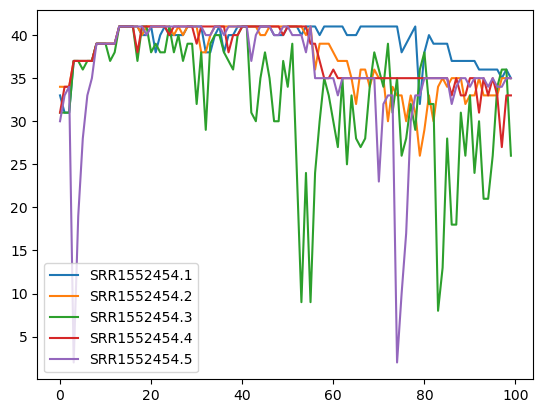

In [63]:
# Using matplotlib
import matplotlib.pyplot as plt

for i in range(5):
    plt.plot(myfq[i].quali, label=myfq[i].name)
plt.legend()
plt.show()

### Using plotnine

In [67]:
import plotnine as pn

# Create a DataFrame from the quality scores
# Reset the index to a new column
quals = pd.DataFrame({myfq[i].name: myfq[i].quali for i in range(5)})
quals = quals.reset_index()
quals

,index,SRR1552454.1,SRR1552454.2,SRR1552454.3,SRR1552454.4,SRR1552454.5
0,0,33,34,31,31,30
1,1,31,34,31,34,33
2,2,31,34,31,34,34
3,3,37,37,37,37,2
4,4,37,37,37,37,19
...,...,...,...,...,...,...
95,95,36,33,26,35,35
96,96,36,33,34,33,34
97,97,35,35,36,27,34
98,98,36,35,36,33,35


In [68]:
# Reshape the DataFrame to long format
quals = quals.melt(id_vars="index",var_name="read", value_name="quality")
quals


,index,read,quality
0,0,SRR1552454.1,33
1,1,SRR1552454.1,31
2,2,SRR1552454.1,31
3,3,SRR1552454.1,37
4,4,SRR1552454.1,37
...,...,...,...
495,95,SRR1552454.5,35
496,96,SRR1552454.5,34
497,97,SRR1552454.5,34
498,98,SRR1552454.5,35


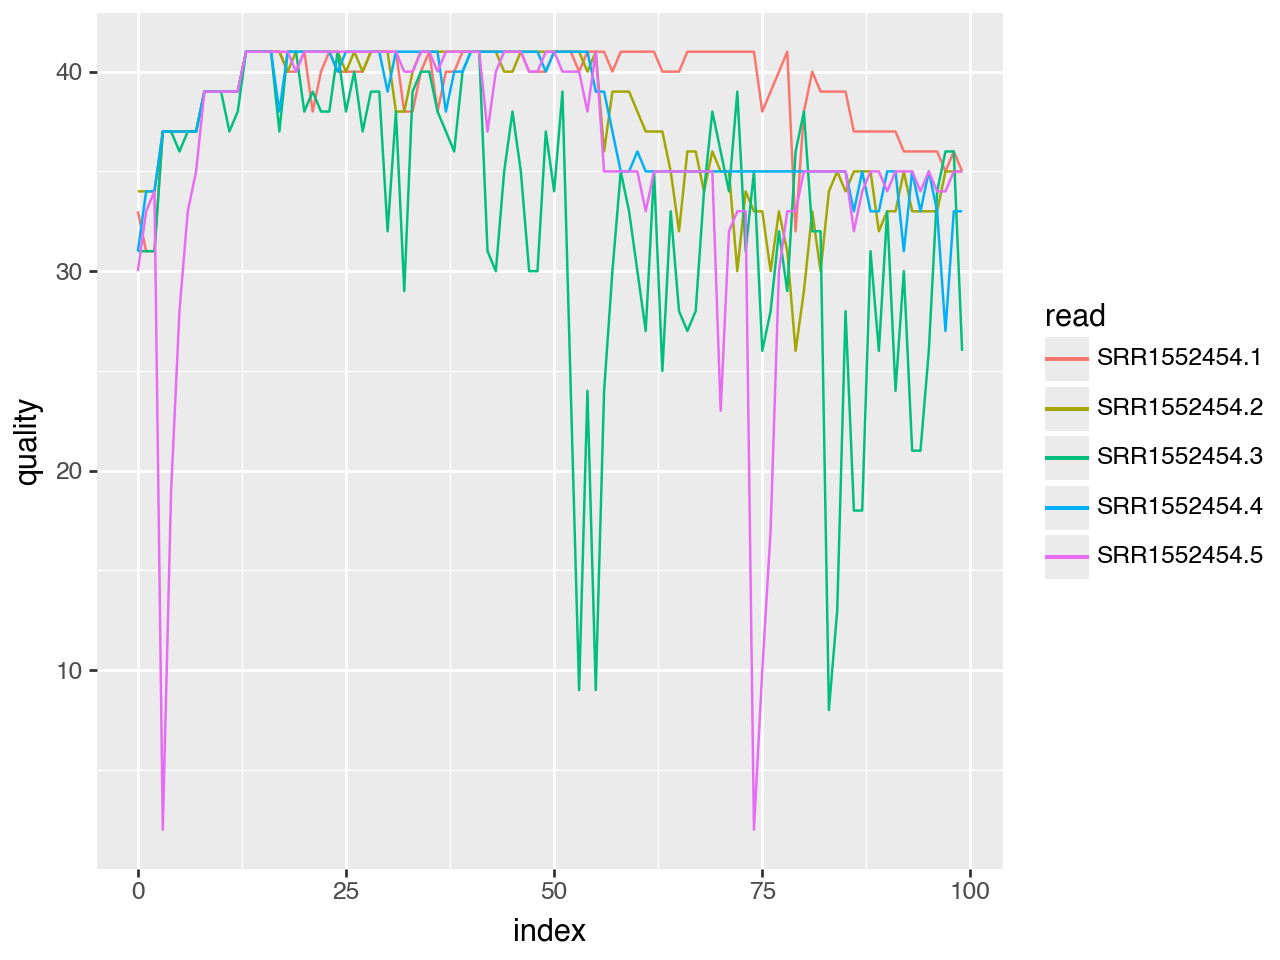

In [66]:

# Create the plot using plotnine
qual_plot = (pn.ggplot(quals, pn.aes(x="index", y="quality", color="read")) 
             + pn.geom_line()
)

qual_plot

Note a couple of things - the beginning quality score is sometimes terrible, and the overall score drops through the read towards the end. This is frequently solved by "trimming" the reads to get the subset of high quality results we trust.

But what was the overall average quality score of the reads?

Let's create a dataframe of the quality scores for all the reads, and then use `plotnine` to plot the distribution of mean quality scores for each read.

In [69]:
import statistics

perread = pd.DataFrame({"qual": [statistics.mean(read.quali) for read in myfq]})
print(perread)


      qual
0    39.19
1    37.33
2    32.79
3    37.49
4    35.81
..     ...
995  38.52
996  31.03
997  37.85
998  36.91
999  38.16

[1000 rows x 1 columns]


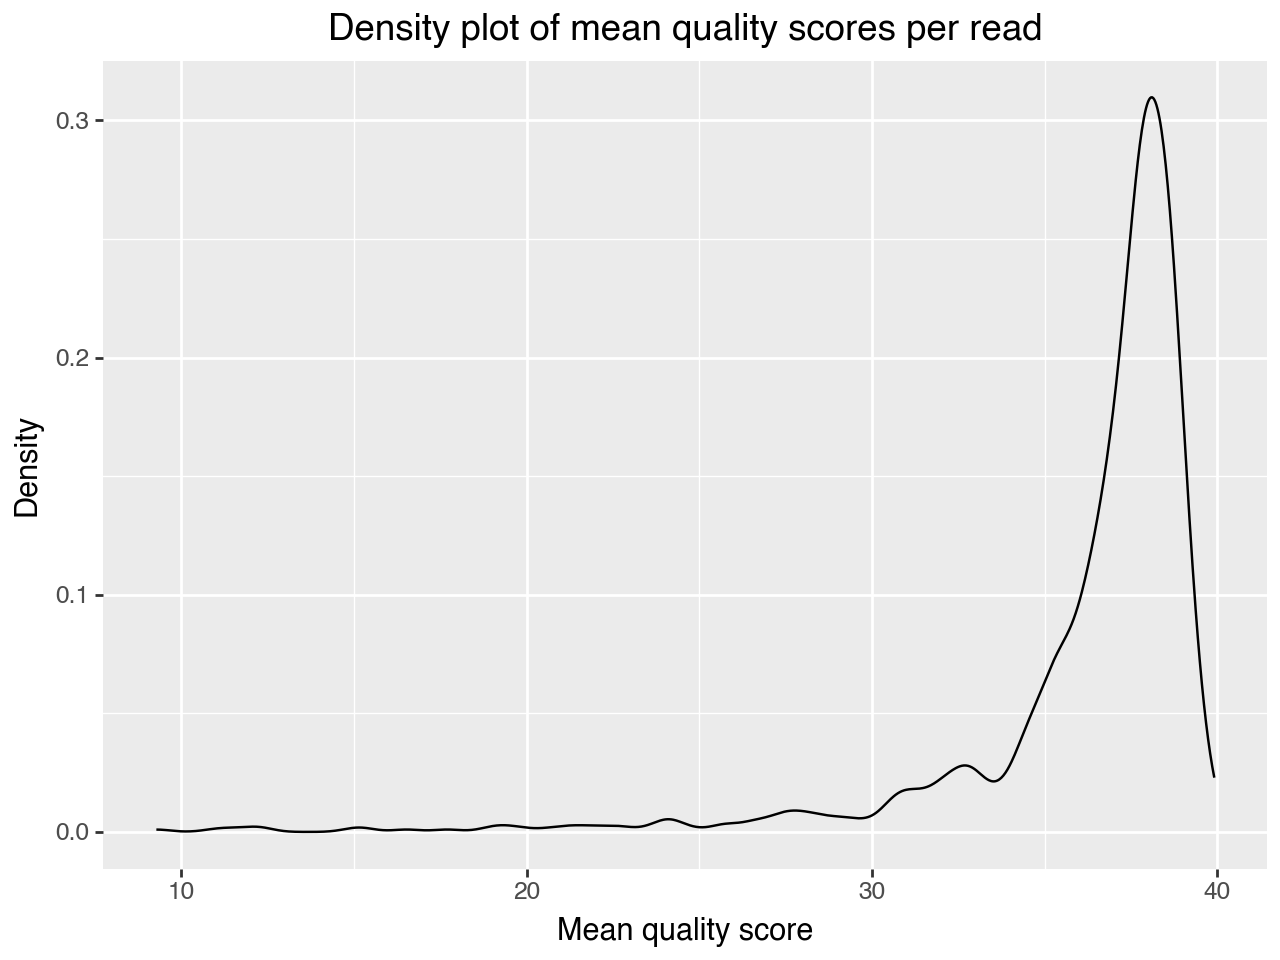

In [70]:

# Let's plot these as a "density" plot - sort of a smoothed histogram
qual_density_plot = (
                pn.ggplot(perread, pn.aes(x="qual")) 
                     + pn.geom_density()
                     + pn.ggtitle("Density plot of mean quality scores per read")
                     + pn.xlab("Mean quality score")
                     + pn.ylab("Density")
                     )

qual_density_plot

So _overall_ our quality scores are very good!

### Align with Hisat2

Ok - so we have the FASTQ, and we have rudimenarily assessed its quality. Now we want to "align" it against a reference genome. We are going to do this with [HiSat2](http://daehwankimlab.github.io/hisat2/) which is an aligner that is designed to work with sequencing data, specifically RNA sequencing data in this case. We'll also pull in samtools to process other things further


At the beginning of this notebook, we downloaded a "reference index" which uses a genome reference (in this case mouse(mm10)) to align against. The index is a specific file to the sequence aligner that uses the "raw" genome sequence to generate rapid alignments, like the index of a book allows you to look up information more rapidly.

Lets create a new directory to hold our alignment results, and then run hisat2 to align the reads against the reference genome index. This helps to organize our project files and keep things tidy.


In [71]:
%%bash
mkdir -p timp_rnaseq_align

Then we are going to align all our data, using a for loop to loop through all the FASTQ files we downloaded. I'm doing this with a system call to the hisat2 command, as well as to samtools:


First, here's an example of the bash command that we will need to run for the first sample (just printed to the screen):

In [73]:
i = 0
print(meta.sampleid[i])
print("Here is the bash command")
print(f"hisat2 -p 4 -x mm10/genome -U timp_rnaseq_data/{meta.destfile[i]} -S timp_rnaseq_align/{meta.sampleid[i]}.sam")

MCL1-DL
Here is the bash command
hisat2 -p 4 -x mm10/genome -U timp_rnaseq_data/MCL1-DL.fq.gz -S timp_rnaseq_align/MCL1-DL.sam


So now we know the syntax of the hisat2 command, we can loop through all the samples in our metadata table and align them all. Notice the `!` at the beginning of the third line, which tells the notebook to run the command in the bash shell instead of in python. This is a convenient way of looping through bash commands using python control flow logic (e.g. for loops, if statements, etc).

In [74]:
for i in range(len(meta)):
    print(f"Aligning sample {meta.sampleid[i]}")
    !hisat2 -p 4 -x mm10/genome -U timp_rnaseq_data/{meta.destfile[i]} -S timp_rnaseq_align/{meta.sampleid[i]}.sam
    

Aligning sample MCL1-DL
1000 reads; of these:
  1000 (100.00%) were unpaired; of these:
    40 (4.00%) aligned 0 times
    892 (89.20%) aligned exactly 1 time
    68 (6.80%) aligned >1 times
96.00% overall alignment rate
Aligning sample MCL1-DK
1000 reads; of these:
  1000 (100.00%) were unpaired; of these:
    41 (4.10%) aligned 0 times
    901 (90.10%) aligned exactly 1 time
    58 (5.80%) aligned >1 times
95.90% overall alignment rate
Aligning sample MCL1-DJ
1000 reads; of these:
  1000 (100.00%) were unpaired; of these:
    35 (3.50%) aligned 0 times
    886 (88.60%) aligned exactly 1 time
    79 (7.90%) aligned >1 times
96.50% overall alignment rate
Aligning sample MCL1-DI
1000 reads; of these:
  1000 (100.00%) were unpaired; of these:
    31 (3.10%) aligned 0 times
    895 (89.50%) aligned exactly 1 time
    74 (7.40%) aligned >1 times
96.90% overall alignment rate
Aligning sample MCL1-DH
1000 reads; of these:
  1000 (100.00%) were unpaired; of these:
    29 (2.90%) aligned 0 tim

As you can see from the output, we get a report on how the reads aligned after each alignment run - it tells us that the reads were unpaired (which we knew) and a small percent of the reads don't align at all, the vast majority align once, and then a couple align multiple times.

- Reads that don't align we can toss, could be contamination, could just be gaps in assembly. As long as these are low it's not a huge concern.
- Reads that align multiple times could be in repetitive sequences or genes (since RNA-seq) with high homology. These are more of a concern to lose, but it's a largely unavoidable problem with short reads.
- The "uniquely" aligned reads are our meat and potatoes.

You can see that now we also have a `.sam` file in our `timp_rnaseq_align` directory - this is the alignment file that tells us where each read aligned in the genome.

In [75]:
!ls timp_rnaseq_align

MCL1-DG.sam MCL1-DI.sam MCL1-DK.sam MCL1-LA.sam MCL1-LC.sam MCL1-LE.sam
MCL1-DH.sam MCL1-DJ.sam MCL1-DL.sam MCL1-LB.sam MCL1-LD.sam MCL1-LF.sam



### SAM files

Let's take a quick look at the alignment file


In [76]:
!tail -n5 timp_rnaseq_align/MCL1-DL.sam

SRR1552455.1000	16	chr8	83316902	60	33M796N67M	*	0	0	GTAAGGTTGATTCCAACTATTGCATAAGAATACCCTAATTTGGGGTGATTTGAGCGGGAGAGAATCTGATGCGCTTCGCTGGTGTAGTTTTCACTGAAAT	DDDDDDDDCDCCDDDCDDCCCDDDDEEEECA>DCDEEEEDFFFHHHAAAG@JJIJJJJJJJJJJIJJJJJJJIJJJJJJJJJJJJJJHHHHHFFFFFCCC	AS:i:0	XN:i:0	XM:i:0	XO:i:0	XG:i:0	NM:i:0	MD:Z:100	YT:Z:UU	XS:A:-	NH:i:1
SRR1552455.998	0	chr11	120346652	1	100M	*	0	0	GCTAGGTGCTAGGGCTGTGATCTCCTTCTGCATCCTGTCAGCAATGCCTGGGTACATGGTGGTACCACCAGACAGCACTGTATTGGCATACAGGTCTTTG	CCCFFFDFHHHHHIJJJJJJJIJJJJJJJJJJJJJJJJJJJJJIIIJJJJJJHHJIIIIIJIIJJJJJJJJHHHHHFFFFFFEFEEEDDDDDDDDDDDDD	AS:i:0	ZS:i:0	XN:i:0	XM:i:0	XO:i:0	XG:i:0	NM:i:0	MD:Z:100	YT:Z:UU	NH:i:3
SRR1552455.998	272	chr4	103564271	1	100M	*	0	0	CAAAGACCTGTATGCCAATACAGTGCTGTCTGGTGGTACCACCATGTACCCAGGCATTGCTGACAGGATGCAGAAGGAGATCACAGCCCTAGCACCTAGC	DDDDDDDDDDDDDEEEFEFFFFFFHHHHHJJJJJJJJIIJIIIIIJHHJJJJJJIIIJJJJJJJJJJJJJJJJJJJJJIJJJJJJJIHHHHHFDFFFCCC	AS:i:0	ZS:i:0	XN:i:0	XM:i:0	XO:i:0	XG:i:0	NM:i:0	MD:Z:100	YT:Z:UU	NH:i:3
SRR1552455.998	272	chr13	8106

I took the last 5 lines in this case because the beginning has a header that we aren't going to get into (with `tail`)

The SAM/BAM file spec is avilable [here](https://samtools.github.io/hts-specs/SAMv1.pdf).

Essentially it's a tab-separated text file with columns as:

- Sequence read name
- Flags (i.e. multiple alignment, etc)
- Reference sequence it's aligned to (in this case the chromomsome)
- Map Quality score (How confident it is of correct alignment on a log scale, 0 is bad, high numbers good)
- CIGAR string - this specifies differences from the reference, with M being matches (and often mismatches), D deletions and I insertions
- RNEXT is used to specify the reference sequence (chromosome) for a paired read if there is one
- PNEXT is used to specify the position of the paired read
- TLEN is the length of the molecule - again if you have paired reads you want to know the distance between the paired start and end
- SEQ is the sequence of the read (from the FASTQ)
- QUAL is the quality of the read (from the FASTQ)
- Extra Alignment Tags

Let's look at some stats of this SAM file


In [77]:
!samtools flagstat timp_rnaseq_align/MCL1-DL.sam

1124 + 0 in total (QC-passed reads + QC-failed reads)
1000 + 0 primary
124 + 0 secondary
0 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
1084 + 0 mapped (96.44% : N/A)
960 + 0 primary mapped (96.00% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


Looking at this, it's the same info, but perhaps a bit easier to parse and putting a nice "Ranges" ojbect for the alignments.

Note we have more than 1000 alignments - that's because we had those reads with multiple alignments! But they'll have the same "qname"

### Gene alignment

Ok - finally let's look at how many of our alignments go to _genes_. To do this, we will use `featureCounts` from the `subread` software tool. This program takes a SAM/BAM file and an annotation file (which tells it where genes are in the genome) and counts how many reads align to each gene.

When we installed `subread` above, it also installed `featureCounts` as a command line tool, and a few 'annotation' files that we can use to map our alignments to features. These are stored in the `annotation` directory of the conda environment.  Let's look at what annotation files we have available:

Note: `$CONDA_PREFIX` is a bash environment variable that points to the root of the conda environment you are currently using.

In [78]:
!ls $CONDA_PREFIX/annotation

hg19_RefSeq_exon.txt    mm10_RefSeq_exon.txt    mm9_RefSeq_exon.txt
hg38_RefSeq_exon.txt    mm39_RefSeq_exon.txt.gz


Since we aligned to the mm10 mouse genome, we will use the `mm10_RefSeq_exon.txt` annotation file (in a Simplified Annotation Format - SAF) that came with the conda install of subread. This is a simple tab-delimited file that specifies where exons are in the genome, and which gene they belong to.

In [79]:
!head -n5 $CONDA_PREFIX/annotation/mm10_RefSeq_exon.txt

GeneID	Chr	Start	End	Strand
497097	chr1	3214482	3216968	-
497097	chr1	3421702	3421901	-
497097	chr1	3670552	3671498	-
100503874	chr1	3647309	3650509	-


So we will pass this annotation file to featureCounts (argument `-a`) along with the format of the annotation file (argument `-F SAF` for Simplified Annotation Format) and then specify an output file (argument `-o`) and finally the SAM file we want to count reads from.

In [80]:
!featureCounts -a $CONDA_PREFIX/annotation/mm10_RefSeq_exon.txt -F SAF -o timp_rnaseq_align/MCL1-DL.counts timp_rnaseq_align/MCL1-DL.sam


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.1.1

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 1 SAM file                                       ||
||                                                                            ||
||                           MCL1-DL.sam                                      ||
||                                                                            ||
||             Output file : MCL1-DL.counts                      

In our alignments directory, we now have two additional files, a `.counts` file which has the gene counts, and a `.counts.summary` file which has a summary of how many reads were assigned to genes.

In [81]:
!cat timp_rnaseq_align/MCL1-DL.counts.summary

Status	timp_rnaseq_align/MCL1-DL.sam
Assigned	765
Unassigned_Unmapped	40
Unassigned_Read_Type	0
Unassigned_Singleton	0
Unassigned_MappingQuality	0
Unassigned_Chimera	0
Unassigned_FragmentLength	0
Unassigned_Duplicate	0
Unassigned_MultiMapping	192
Unassigned_Secondary	0
Unassigned_NonSplit	0
Unassigned_NoFeatures	91
Unassigned_Overlapping_Length	0
Unassigned_Ambiguity	36



So most of our reads are actually assigned to a gene - this is great.

We can even see what gene and how many counts - then filter out genes with no counts, and sort by number of counts


In [82]:
genecounts = pd.read_csv(
    "timp_rnaseq_align/MCL1-DL.counts", delimiter="\t", comment="#"
)

# Filter out only genes with >0 counts
genecounts = genecounts[genecounts["timp_rnaseq_align/MCL1-DL.sam"] > 0]

# Sort on highest counts
genecounts.sort_values(by="timp_rnaseq_align/MCL1-DL.sam", ascending=False)

,Geneid,Chr,Start,End,Strand,Length,timp_rnaseq_align/MCL1-DL.sam
12139,11475,chr19;chr19;chr19;chr19;chr19;chr19;chr19;chr1...,34241091;34243317;34244912;34246078;34246652;3...,34241810;34243498;34245103;34246239;34246736;3...,-;-;-;-;-;-;-;-;-,1780,13
9019,17880,chr16;chr16;chr16;chr16;chr16;chr16;chr16;chr1...,14194527;14198050;14200695;14200969;14202063;1...,14195184;14198088;14200867;14201077;14202271;1...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;...,6632,12
26230,192176,chrX;chrX;chrX;chrX;chrX;chrX;chrX;chrX;chrX;c...,74223461;74224752;74225040;74225398;74226202;7...,74223977;74224955;74225258;74225574;74226334;7...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;...,8347,9
25628,17711,chrM,14145,15288,+,1144,8
5138,14281,chr12;chr12;chr12;chr12,85473901;85474935;85475592;85475817,85474180;85475186;85475699;85477269,+;+;+;+,2093,7
...,...,...,...,...,...,...,...
8982,56722,chr16;chr16;chr16;chr16,10959273;10963257;10966425;10993046,10961051;10963413;10966649;10993121,-;-;-;-,2237,1
8832,110308,chr15;chr15;chr15;chr15;chr15;chr15;chr15;chr1...,101707070;101708117;101708876;101709753;101710...,101707722;101708151;101709096;101709878;101710...,-;-;-;-;-;-;-;-;-,2190,1
8810,15370,chr15;chr15;chr15;chr15;chr15;chr15;chr15,101266846;101270083;101271736;101272153;101272...,101266971;101270969;101271865;101272304;101272...,+;+;+;+;+;+;+,2477,1
8775,65970,chr15;chr15;chr15;chr15;chr15;chr15;chr15;chr1...,99778468;99783520;99794409;99796742;99802111;9...,99781290;99783653;99794518;99796799;99802212;9...,-;-;-;-;-;-;-;-;-;-;-,4429,1


And look! GeneID 11475 - which is [https://www.ncbi.nlm.nih.gov/gene/11475] actin! A very highly expressed gene, so this makes perfect sense.

Other highly expressed genes include [Myosin - 17880](https://www.ncbi.nlm.nih.gov/gene/17880) and [Filamin - 192176](https://www.ncbi.nlm.nih.gov/gene/192176).

Remember, this is only a sample of 1000 reads in the data, so we aren't going to see a huge number of genes, and likely only the most highly expressed genes, but this is a good start!
